## Setups and Imports

In [ ]:
!pip install -q datasets transformers

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

In [ ]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


## Loading and Preprocessing

In [ ]:
SEED = 36

In [ ]:
# creates a seed reset function to be sure we have the same randomizer always
def set_seed(seed=36):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

In [ ]:
# Set SEED 36
set_seed(SEED)

In [ ]:
# Load the dataset
print("Loading AG News...")
dataset = load_dataset("sh0416/ag_news")
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

def clean_text(df):
    # Combine title and description just like in A1
    df["x_text"] = df["title"].astype(str) + " " + df["description"].astype(str)
    # Basic cleaning: lowercase and remove backslashes
    df["x_text"] = df["x_text"].str.replace("\\", " ", regex=False).str.lower()
    return df

train_df = clean_text(train_df)
test_df = clean_text(test_df)

# Split train into train (90%) and validation (10%) using SEED 36
train, val = train_test_split(train_df, test_size=0.1, random_state=SEED)

print(f"Train size: {len(train)} | Val size: {len(val)} | Test size: {len(test_df)}")

Loading AG News...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.jsonl:   0%|          | 0.00/33.7M [00:00<?, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Train size: 108000 | Val size: 12000 | Test size: 7600


In [ ]:
train["label"] = train["label"] - 1
val["label"] = val["label"] - 1
test_df["label"] = test_df["label"] - 1

In [ ]:
train_tf = train.rename(columns={"x_text": "text"})
val_tf = val.rename(columns={"x_text": "text"})
test_tf = test_df.rename(columns={"x_text": "text"})

train_ds = Dataset.from_pandas(train_tf[["text", "label"]].reset_index(drop=True))
val_ds = Dataset.from_pandas(val_tf[["text", "label"]].reset_index(drop=True))
test_ds = Dataset.from_pandas(test_tf[["text", "label"]].reset_index(drop=True))

## Metrics

In [ ]:
#setting up accuracy function
def accuracy(y_true, y_pred):
    #set y_true and y_pred as numpy arrays so we can use (i, len(y_pred)) as positional arguments
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    #initialize correct prediction count as 0
    same = 0
    for i in range(len(y_pred)):
        if y_true[i] == y_pred[i]:
            #if prediction was right, increse the count
            same += 1
    #return the accuracy
    return same / len(y_pred)

#setting a function that returns True Positives, True Negatives, False Positives and False Negatives, per label
def metrics(label, y_true, y_pred):
    tp = 0
    fp = 0
    fn = 0
    tn = 0
    for yt, yp in zip(y_true, y_pred):
        if yt == label and yp == label:
            tp += 1
        elif yt != label and yp == label:
            fp += 1
        elif yt == label and yp != label:
            fn += 1
        else:
            tn += 1
    return tp, fp, fn, tn

#calculates the f1-score given a label
def f1(label, y_true, y_pred):
    tp, fp, fn, tn = metrics(label, y_true, y_pred)
    precision = tp / (tp + fp) if tp + fp != 0 else 0
    recall = tp / (tp + fn) if tp + fn != 0 else 0
    return 2 * (precision * recall) / (precision + recall)


#calculates the macro f1 (average f1)
def macro_f1(y_true, y_pred):
    labels = sorted(set(y_true) | set(y_pred))
    sum = 0
    for label in labels:
        sum += f1(label, y_true, y_pred)
    return sum / 4

# uses sklearn's confusion matrix function
def conf_matrix(y_true, y_pred, class_names=["World", "Sports", "Business", "Sci/Tech"], normalize=False, save_path=None):
    cm = confusion_matrix(y_true, y_pred)

    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(
        cmap="Blues",
        values_format=".2f" if normalize else "d",
        ax=ax,
        colorbar=True
    )

    #ax.set_title("Normalized Confusion Matrix (Test Set)" if normalize else "Confusion Matrix (Test Set)")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy(labels, preds),
        "macro_f1": macro_f1(labels, preds)
    }

## Tokenizer

In [ ]:
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

max_length = 128

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=max_length
    )

tokenized_train = train_ds.map(tokenize_function, batched=True)
tokenized_val = val_ds.map(tokenize_function, batched=True)
tokenized_test = test_ds.map(tokenize_function, batched=True)

Map:   0%|          | 0/108000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

## Model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=4
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./agnews_distilbert_50",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none"
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.234062,0.210693,0.933083,0.933507
2,0.142760,0.197866,0.941167,0.941633
3,0.097532,0.260442,0.940250,0.940701
4,0.063776,0.296847,0.940500,0.940921


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=27000, training_loss=0.1345323531539352, metrics={'train_runtime': 4241.7583, 'train_samples_per_second': 101.845, 'train_steps_per_second': 6.365, 'total_flos': 1.0217558318209536e+16, 'train_loss': 0.1345323531539352, 'epoch': 4.0})

## Testing

In [ ]:
test_output = trainer.predict(tokenized_test)
test_logits = test_output.predictions
test_labels = test_output.label_ids
test_preds = np.argmax(test_logits, axis=-1)

In [ ]:
print("Test Accuracy:", accuracy(test_labels, test_preds))
print("Test Macro-F1:", macro_f1(test_labels, test_preds))

Test Accuracy: 0.944078947368421
Test Macro-F1: 0.9441832891652846


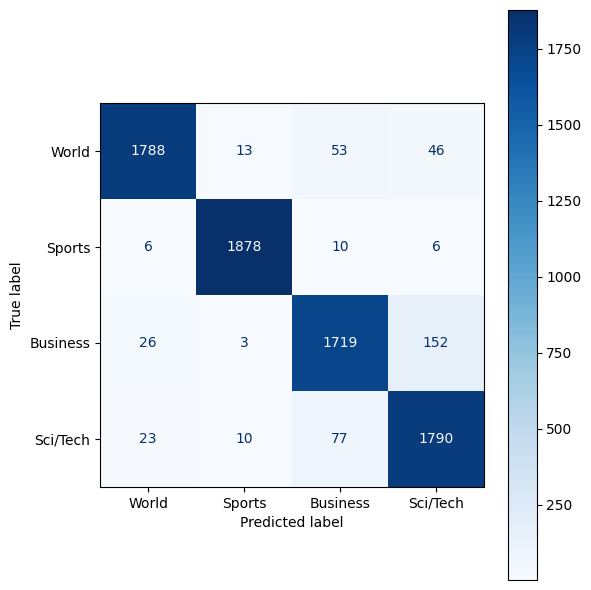

In [ ]:
conf_matrix(test_labels, test_preds)

## Robustness/Slice

### Bins

In [ ]:
results_df = test_tf.copy().reset_index(drop=True)
results_df["true_label"] = test_labels
results_df["pred_label"] = test_preds
results_df["correct"] = (results_df["true_label"] == results_df["pred_label"]).astype(int)

results_df.head()

,label,title,description,text,true_label,pred_label,correct
0,2,Fears for T N pension after talks,Unions representing workers at Turner Newall...,fears for t n pension after talks unions repre...,2,2,1
1,3,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o...",the race is on: second private team sets launc...,3,3,1
2,3,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...,ky. company wins grant to study peptides (ap) ...,3,3,1
3,3,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...,prediction unit helps forecast wildfires (ap) ...,3,3,1
4,3,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...,calif. aims to limit farm-related smog (ap) ap...,3,3,1


In [ ]:
results_df["word_count"] = results_df["text"].apply(lambda x: len(str(x).split()))

results_df["length_bucket"] = pd.cut(
    results_df["word_count"],
    bins=[0, 20, 40, 60, 1000],
    labels=["0-20", "21-40", "41-60", "61+"]
)

slice_results = []
for bucket in results_df["length_bucket"].dropna().unique():
    subset = results_df[results_df["length_bucket"] == bucket]
    slice_results.append({
        "length_bucket": str(bucket),
        "n": len(subset),
        "accuracy": accuracy(subset["true_label"].tolist(), subset["pred_label"].tolist()),
        "macro_f1": macro_f1(subset["true_label"].tolist(), subset["pred_label"].tolist())
    })

slice_df = pd.DataFrame(slice_results).sort_values("length_bucket")
slice_df

,length_bucket,n,accuracy,macro_f1
3,0-20,206,0.902913,0.877521
0,21-40,4712,0.941638,0.941068
1,41-60,2508,0.953349,0.953294
2,61+,174,0.925287,0.896435


### Reduced size training

In [ ]:
train_25 = train.sample(frac=0.25, random_state=SEED).reset_index(drop=True)
train_50 = train.sample(frac=0.50, random_state=SEED).reset_index(drop=True)

train_tf_50 = train_50.rename(columns={"x_text": "text"})
train_tf_25 = train_25.rename(columns={"x_text": "text"})

train_ds_50 = Dataset.from_pandas(train_tf_50[["text", "label"]].reset_index(drop=True))
train_ds_25 = Dataset.from_pandas(train_tf_25[["text", "label"]].reset_index(drop=True))

In [ ]:
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

max_length = 128

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


In [ ]:
tokenized_train_50 = train_ds_50.map(tokenize_function, batched=True)
tokenized_train_25 = train_ds_25.map(tokenize_function, batched=True)
tokenized_val = val_ds.map(tokenize_function, batched=True)
tokenized_test = test_ds.map(tokenize_function, batched=True)

Map:   0%|          | 0/54000 [00:00<?, ? examples/s]

Map:   0%|          | 0/27000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

#### 50%

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=4
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
training_args = TrainingArguments(
    output_dir="./agnews_distilbert_50",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none"
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_50,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.266327,0.232769,0.928417,0.928855
2,0.156835,0.233995,0.934417,0.934920
3,0.102847,0.289006,0.931417,0.931874
4,0.064336,0.329567,0.930667,0.931095


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=13500, training_loss=0.14758602679217303, metrics={'train_runtime': 2270.2843, 'train_samples_per_second': 95.142, 'train_steps_per_second': 5.946, 'total_flos': 5113403264161920.0, 'train_loss': 0.14758602679217303, 'epoch': 4.0})

In [ ]:
test_output = trainer.predict(tokenized_test)
test_logits = test_output.predictions
test_labels = test_output.label_ids
test_preds = np.argmax(test_logits, axis=-1)

In [ ]:
print("Test Accuracy 50%:", accuracy(test_labels, test_preds))
print("Test Macro-F1 50%:", macro_f1(test_labels, test_preds))

Test Accuracy 50%: 0.9394736842105263
Test Macro-F1 50%: 0.9395811833012286


#### 25%

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=4
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
training_args = TrainingArguments(
    output_dir="./agnews_distilbert_25",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none"
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_25,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.302378,0.247691,0.918583,0.918982
2,0.170470,0.259290,0.923833,0.924359
3,0.106283,0.320061,0.923250,0.923610
4,0.068839,0.341880,0.924833,0.925295


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=6752, training_loss=0.16199229791831066, metrics={'train_runtime': 1354.7692, 'train_samples_per_second': 79.718, 'train_steps_per_second': 4.984, 'total_flos': 2563192766127168.0, 'train_loss': 0.16199229791831066, 'epoch': 4.0})

In [ ]:
test_output = trainer.predict(tokenized_test)
test_logits = test_output.predictions
test_labels = test_output.label_ids
test_preds = np.argmax(test_logits, axis=-1)

In [ ]:
print("Test Accuracy 25%:", accuracy(test_labels, test_preds))
print("Test Macro-F1 25%:", macro_f1(test_labels, test_preds))

Test Accuracy 25%: 0.9336842105263158
Test Macro-F1 25%: 0.9337029857976206


## Model states download

In [ ]:
!zip -r full_training.zip agnews_distilbert

  adding: agnews_distilbert/ (stored 0%)
  adding: agnews_distilbert/checkpoint-6750/ (stored 0%)
  adding: agnews_distilbert/checkpoint-6750/trainer_state.json (deflated 60%)
  adding: agnews_distilbert/checkpoint-6750/optimizer.pt (deflated 16%)
  adding: agnews_distilbert/checkpoint-6750/tokenizer_config.json (deflated 42%)
  adding: agnews_distilbert/checkpoint-6750/scheduler.pt (deflated 61%)
  adding: agnews_distilbert/checkpoint-6750/training_args.bin (deflated 53%)
  adding: agnews_distilbert/checkpoint-6750/tokenizer.json (deflated 71%)
  adding: agnews_distilbert/checkpoint-6750/rng_state.pth (deflated 26%)
  adding: agnews_distilbert/checkpoint-6750/config.json (deflated 53%)
  adding: agnews_distilbert/checkpoint-6750/model.safetensors (deflated 8%)
  adding: agnews_distilbert/checkpoint-27000/ (stored 0%)
  adding: agnews_distilbert/checkpoint-27000/trainer_state.json (deflated 69%)
  adding: agnews_distilbert/checkpoint-27000/optimizer.pt (deflated 16%)
  adding: agnews_d

In [ ]:
!zip -r 50_training.zip agnews_distilbert_50

  adding: agnews_distilbert_50/ (stored 0%)
  adding: agnews_distilbert_50/checkpoint-3375/ (stored 0%)
  adding: agnews_distilbert_50/checkpoint-3375/trainer_state.json (deflated 60%)
  adding: agnews_distilbert_50/checkpoint-3375/optimizer.pt (deflated 17%)
  adding: agnews_distilbert_50/checkpoint-3375/tokenizer_config.json (deflated 42%)
  adding: agnews_distilbert_50/checkpoint-3375/scheduler.pt (deflated 61%)
  adding: agnews_distilbert_50/checkpoint-3375/training_args.bin (deflated 53%)
  adding: agnews_distilbert_50/checkpoint-3375/tokenizer.json (deflated 71%)
  adding: agnews_distilbert_50/checkpoint-3375/rng_state.pth (deflated 26%)
  adding: agnews_distilbert_50/checkpoint-3375/config.json (deflated 53%)
  adding: agnews_distilbert_50/checkpoint-3375/model.safetensors (deflated 8%)
  adding: agnews_distilbert_50/checkpoint-6750/ (stored 0%)
  adding: agnews_distilbert_50/checkpoint-6750/trainer_state.json (deflated 64%)
  adding: agnews_distilbert_50/checkpoint-6750/optimiz

In [ ]:
!zip -r 25_training.zip agnews_distilbert_25

  adding: agnews_distilbert_25/ (stored 0%)
  adding: agnews_distilbert_25/checkpoint-5064/ (stored 0%)
  adding: agnews_distilbert_25/checkpoint-5064/trainer_state.json (deflated 67%)
  adding: agnews_distilbert_25/checkpoint-5064/optimizer.pt (deflated 18%)
  adding: agnews_distilbert_25/checkpoint-5064/tokenizer_config.json (deflated 42%)
  adding: agnews_distilbert_25/checkpoint-5064/scheduler.pt (deflated 61%)
  adding: agnews_distilbert_25/checkpoint-5064/training_args.bin (deflated 53%)
  adding: agnews_distilbert_25/checkpoint-5064/tokenizer.json (deflated 71%)
  adding: agnews_distilbert_25/checkpoint-5064/rng_state.pth (deflated 26%)
  adding: agnews_distilbert_25/checkpoint-5064/config.json (deflated 53%)
  adding: agnews_distilbert_25/checkpoint-5064/model.safetensors (deflated 8%)
  adding: agnews_distilbert_25/checkpoint-3376/ (stored 0%)
  adding: agnews_distilbert_25/checkpoint-3376/trainer_state.json (deflated 64%)
  adding: agnews_distilbert_25/checkpoint-3376/optimiz

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive

 15a1d4ea-b58d-4613-b58e-97fbead8629a.mp4
 1C26BE8E-A4A1-4F58-8EAD-46B5DF544C45-1000x650.jpeg
 20230306_171256.jpg
 20230306_171414.jpg
 20230306_211840.jpg
 20230306_211840.pdf
 20250528_113931.jpg
 aaaaaaaaasodmalkamdoeuaaaaaaaaaaaaaaaaaaaaaaaaaaaa.gdoc
 ares.mp4
 atividade3_14568142.gdoc
 Atividade_4_14568142.gdoc
'Atividade 6.gdoc'
 Atividade_6_pt1_14568142.pdf
 Atividade_6_pt2_14568142.pdf
'Biblioteca-Review (1).gdoc'
'Biblioteca-Review (2).gdoc'
 Biblioteca-Review.gdoc
'Bingo Sacim.gsheet'
 BrayWyattDocumentary
 Carta.gdoc
'Carvalho - Feito com o Clipchamp_1770496663169.mp4'
'Colab Notebooks'
 colonoscopia.pdf
 com-mod-criminal-case-v2-39-mod-1796111.apk
'COMPROVANTE RESIDENCIA MURILO.pdf'
 contrato.pdf
'Controle Financeiro.gsheet'
 converted_image.jpg
'Copy of 2023-06-06 18-15-15.mkv'
'Copy of Apresentação Trabalho 1.mkv'
'Copy of Trabalho 1!'
'CPF Enzo (1).pdf'
'CPF Enzo (2).pdf'
'CPF Enzo.pdf'
 Criminal-Case-2.38.2-Mod-TechBigs.Com.apk
'Currículo 05092021.gdoc'
'Curriculo 1

In [ ]:
!cp /content/25_training.zip /content/drive/MyDrive/
!cp /content/50_training.zip /content/drive/MyDrive/
!cp /content/full_training.zip /content/drive/MyDrive/